# CNN sobre CIFAR-10 con TensorFlow/Keras

CIFAR-10 contiene diez clases: avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco y camión. El objetivo es entrenar una CNN con augmentation exclusivo de train, callbacks controlados por validation y test final único.

> Dependencias: `requirements/common.txt` y `requirements/tensorflow.txt`.

## 1. Configuración reproducible

In [1]:
import hashlib,io,json,os,platform,random,subprocess,sys,time,urllib.request
from datetime import datetime,timezone
from pathlib import Path
import numpy as np

def localizar_tema2():
    cwd=Path.cwd().resolve()
    for p in [cwd,cwd/"tema-02-machine-learning",*cwd.parents]:
        if p.name=="tema-02-machine-learning" and (p/".tema2-root").exists():return p
    raise FileNotFoundError("No se localizó Tema 2")
TEMA2_ROOT=localizar_tema2()
os.environ["KERAS_HOME"]=str(TEMA2_ROOT/".data"/"keras")
os.environ["TF_DETERMINISTIC_OPS"]="1";os.environ["TF_CPP_MIN_LOG_LEVEL"]="2"
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
import sklearn
import tensorflow as tf
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay,accuracy_score,classification_report,confusion_matrix,f1_score,precision_score,recall_score
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
RUN_MODE=os.getenv("RUN_MODE","full").lower()
if RUN_MODE not in {"fast","full"}:raise ValueError("RUN_MODE debe ser fast o full")
SEED=42;random.seed(SEED);np.random.seed(SEED);tf.keras.utils.set_random_seed(SEED)
try:tf.config.experimental.enable_op_determinism()
except Exception:pass
RESULTS_ROOT=TEMA2_ROOT/"03-redes-multicapa-convolucionales-vision"/"results"/"04_cnn_cifar10_keras"
DATA_DIR=TEMA2_ROOT/".data"/"cifar10"
RUN_DIR=RESULTS_ROOT/"experiments"/RUN_MODE/"cifar10_cnn";CHECKPOINT_DIR=RESULTS_ROOT/"checkpoints"
DATA_DIR.mkdir(parents=True,exist_ok=True);RUN_DIR.mkdir(parents=True,exist_ok=True);CHECKPOINT_DIR.mkdir(parents=True,exist_ok=True)
PUBLISHABLE=RUN_MODE=="full";device="gpu" if tf.config.list_physical_devices("GPU") else "cpu"
CLASS_NAMES=["avión","automóvil","pájaro","gato","ciervo","perro","rana","caballo","barco","camión"]
print(f"RUN_MODE={RUN_MODE} publishable={PUBLISHABLE} TensorFlow={tf.__version__} device={device}")

RUN_MODE=full publishable=True TensorFlow=2.15.1 device=cpu


## 2. Dataset y particiones

El train oficial se divide estratificadamente. Los píxeles se normalizan a `[0,1]`. CIFAR-10 es más complejo que MNIST por color, fondos y variabilidad dentro de cada clase.

Train=45000 Validation=5000 Test=10000


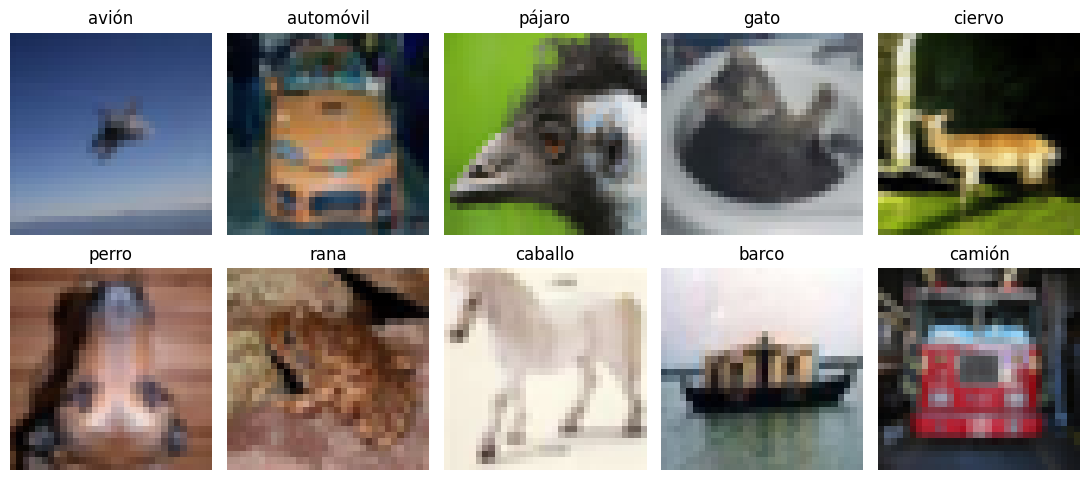

In [2]:
FILES={
 "train.parquet":("https://huggingface.co/datasets/uoft-cs/cifar10/resolve/main/plain_text/train-00000-of-00001.parquet?download=true","8428b53a88a11ac374111006708df51469e315a22ac6d66470afd9c78d2ae883"),
 "test.parquet":("https://huggingface.co/datasets/uoft-cs/cifar10/resolve/main/plain_text/test-00000-of-00001.parquet?download=true","841389e6f2d64f28bf17310e430aebac20ec3ba611a3c5e231dc93c645ce84de")}
def sha256(path):
    h=hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda:f.read(1024*1024),b""):h.update(chunk)
    return h.hexdigest()
def asegurar(nombre,url,expected):
    path=DATA_DIR/nombre
    if not path.exists():
        temp=path.with_suffix(".tmp");urllib.request.urlretrieve(url,temp);temp.replace(path)
    if sha256(path)!=expected:raise ValueError(f"Hash inválido: {path}")
    return path
paths={name:asegurar(name,*info) for name,info in FILES.items()}
def cargar_parquet(path):
    table=pq.read_table(path,columns=["img","label"]).to_pylist()
    X=np.stack([np.asarray(Image.open(io.BytesIO(row["img"]["bytes"])).convert("RGB"),dtype=np.uint8) for row in table])
    y=np.asarray([row["label"] for row in table],dtype=np.int64)
    return X,y
X_all,y_all=cargar_parquet(paths["train.parquet"]);X_test,y_test=cargar_parquet(paths["test.parquet"])
X_train,X_val,y_train,y_val=train_test_split(X_all,y_all,test_size=.1,stratify=y_all,random_state=SEED)
def limitar(X,y,n,seed):
    if len(y)<=n:return X,y
    a,_,b,_=train_test_split(X,y,train_size=n,stratify=y,random_state=seed);return a,b
if RUN_MODE=="fast":
    X_train,y_train=limitar(X_train,y_train,8000,SEED)
    X_val,y_val=limitar(X_val,y_val,1800,SEED+1)
    X_test,y_test=limitar(X_test,y_test,2000,SEED+2)
X_train=X_train.astype("float32")/255;X_val=X_val.astype("float32")/255;X_test=X_test.astype("float32")/255
print(f"Train={len(y_train)} Validation={len(y_val)} Test={len(y_test)}")
fig,axes=plt.subplots(2,5,figsize=(11,5))
for c,ax in enumerate(axes.ravel()):
    i=np.flatnonzero(y_train==c)[0];ax.imshow(X_train[i]);ax.set_title(CLASS_NAMES[c]);ax.axis("off")
plt.tight_layout();plt.show()

## 3. Arquitectura y augmentation

El augmentation (flip horizontal y traslación ligera) está dentro del modelo y solo se activa durante `fit`. Validation y test pasan por transformaciones deterministas. La CNN usa dos bloques convolucionales, BatchNorm, pooling y Dropout.

In [3]:
augmentation=keras.Sequential([
    layers.RandomFlip("horizontal",seed=SEED),
    layers.RandomTranslation(.08,.08,seed=SEED),
],name="augmentation_train_only")
model=keras.Sequential([
    layers.Input((32,32,3)),augmentation,
    layers.Conv2D(32,3,padding="same",activation="relu"),layers.BatchNormalization(),
    layers.Conv2D(32,3,padding="same",activation="relu"),layers.MaxPooling2D(),layers.Dropout(.2),
    layers.Conv2D(64,3,padding="same",activation="relu"),layers.BatchNormalization(),
    layers.Conv2D(64,3,padding="same",activation="relu"),layers.MaxPooling2D(),layers.Dropout(.3),
    layers.Flatten(),layers.Dense(128,activation="relu"),layers.Dropout(.4),
    layers.Dense(10,activation="softmax")
],name="cnn_cifar10_keras")
model.compile(optimizer=keras.optimizers.Adam(.001),loss="sparse_categorical_crossentropy",metrics=["accuracy"])
parameters=model.count_params();model.summary()

Model: "cnn_cifar10_keras"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 augmentation_train_only (S  (None, 32, 32, 3)         0         


 equential)                                                      


...

 dense_1 (Dense)             (None, 10)                1290      


Total params: 591658 (2.26 MB)


Trainable params: 591466 (2.26 MB)


Non-trainable params: 192 (768.00 Byte)


_________________________________________________________________


## 4. Entrenamiento controlado por validation

In [4]:
checkpoint=str(CHECKPOINT_DIR/f"cifar10_{RUN_MODE}.keras")
callbacks=[
 keras.callbacks.ModelCheckpoint(checkpoint,monitor="val_loss",mode="min",save_best_only=True),
 keras.callbacks.EarlyStopping(monitor="val_loss",mode="min",patience=4,restore_best_weights=True),
 keras.callbacks.ReduceLROnPlateau(monitor="val_loss",mode="min",factor=.5,patience=2,min_lr=1e-5)]
epochs=2 if RUN_MODE=="fast" else 35
start=time.perf_counter()
h=model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=epochs,batch_size=128,callbacks=callbacks,verbose=2)
training_seconds=time.perf_counter()-start
model=keras.models.load_model(checkpoint)
history=pd.DataFrame(h.history);history.insert(0,"epoch",np.arange(1,len(history)+1));best_epoch=int(history.val_loss.idxmin()+1)
print(f"Mejor época={best_epoch} tiempo={training_seconds:.2f}s")

Epoch 1/35


352/352 - 47s - loss: 1.9904 - accuracy: 0.2476 - val_loss: 2.3182 - val_accuracy: 0.1836 - lr: 0.0010 - 47s/epoch - 135ms/step


Epoch 2/35


352/352 - 41s - loss: 1.7295 - accuracy: 0.3295 - val_loss: 1.4960 - val_accuracy: 0.4556 - lr: 0.0010 - 41s/epoch - 116ms/step


Epoch 3/35


...

Epoch 23/35


352/352 - 40s - loss: 0.7495 - accuracy: 0.7409 - val_loss: 0.6611 - val_accuracy: 0.7694 - lr: 1.2500e-04 - 40s/epoch - 115ms/step


Epoch 24/35


352/352 - 40s - loss: 0.7444 - accuracy: 0.7430 - val_loss: 0.6678 - val_accuracy: 0.7626 - lr: 1.2500e-04 - 40s/epoch - 115ms/step


Mejor época=20 tiempo=999.89s


## 5. Evaluación final, clases confundidas y artefactos

In [5]:
prob=model.predict(X_test,batch_size=256,verbose=0);y_pred=prob.argmax(1)
report=pd.DataFrame(classification_report(y_test,y_pred,target_names=CLASS_NAMES,output_dict=True,zero_division=0)).T
metrics={"experiment_id":"cifar10_cnn","task":"multiclass_classification","classes":CLASS_NAMES,
"train_samples":len(y_train),"validation_samples":len(y_val),"test_samples":len(y_test),
"epochs_or_iterations_completed":len(history),"best_epoch_or_iteration":best_epoch,"parameters":parameters,
"training_seconds":training_seconds,"best_validation_accuracy":float(history.loc[best_epoch-1,"val_accuracy"]),
"test_accuracy":accuracy_score(y_test,y_pred),"test_precision":precision_score(y_test,y_pred,average="macro",zero_division=0),
"test_recall":recall_score(y_test,y_pred,average="macro",zero_division=0),"test_f1":f1_score(y_test,y_pred,average="macro",zero_division=0),
"test_macro_precision":precision_score(y_test,y_pred,average="macro",zero_division=0),"test_macro_recall":recall_score(y_test,y_pred,average="macro",zero_division=0),
"test_macro_f1":f1_score(y_test,y_pred,average="macro",zero_division=0),"test_balanced_accuracy":recall_score(y_test,y_pred,average="macro"),"test_specificity":None}
(RUN_DIR/"metrics.json").write_text(json.dumps(metrics,indent=2,ensure_ascii=False),encoding="utf-8")
history.to_csv(RUN_DIR/"training_history.csv",index=False);report.to_csv(RUN_DIR/"classification_report.csv")
display(pd.Series(metrics,name="valor").to_frame());display(report)

,valor
experiment_id,cifar10_cnn
task,multiclass_classification
classes,"[avión, automóvil, pájaro, gato, ciervo, perro..."
train_samples,45000
validation_samples,5000
test_samples,10000
epochs_or_iterations_completed,24
best_epoch_or_iteration,20
parameters,591658
training_seconds,999.885025


,precision,recall,f1-score,support
avión,0.789526,0.7990,0.794235,1000.0000
automóvil,0.919033,0.8740,0.895951,1000.0000
pájaro,0.727047,0.5860,0.648948,1000.0000
gato,0.592784,0.5750,0.583756,1000.0000
ciervo,0.729651,0.7530,0.741142,1000.0000
perro,0.732587,0.5890,0.652993,1000.0000
rana,0.662366,0.9240,0.771608,1000.0000
caballo,0.878271,0.7720,0.821714,1000.0000
barco,0.862464,0.9030,0.882267,1000.0000
camión,0.817935,0.9030,0.858365,1000.0000


In [6]:
def guardar(fig,n):fig.savefig(RUN_DIR/n,dpi=140,bbox_inches="tight");plt.close(fig)
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(history.epoch,history.loss,label="train");ax[0].plot(history.epoch,history.val_loss,label="validation");ax[0].axvline(best_epoch,ls="--",c="gray");ax[0].legend();ax[0].set(title="Loss",xlabel="Época")
ax[1].plot(history.epoch,history.accuracy,label="train");ax[1].plot(history.epoch,history.val_accuracy,label="validation");ax[1].legend();ax[1].set(title="Accuracy",xlabel="Época");fig.tight_layout();guardar(fig,"learning_curves.png")
cm=confusion_matrix(y_test,y_pred,labels=range(10));fig,a=plt.subplots(figsize=(9,8));ConfusionMatrixDisplay(cm,display_labels=CLASS_NAMES).plot(cmap="Blues",ax=a,values_format="d",xticks_rotation=45);guardar(fig,"confusion_matrix.png")
def ejemplos(indices,title,n):
    fig,axes=plt.subplots(2,5,figsize=(12,5))
    for a in axes.ravel():a.axis("off")
    for a,i in zip(axes.ravel(),indices[:10]):a.imshow(X_test[i]);a.set_title(f"R={CLASS_NAMES[y_test[i]]}\nP={CLASS_NAMES[y_pred[i]]}",fontsize=8);a.axis("off")
    fig.suptitle(title);fig.tight_layout();guardar(fig,n)
ejemplos(np.flatnonzero(y_test==y_pred),"Predicciones correctas","sample_predictions.png")
ejemplos(np.flatnonzero(y_test!=y_pred),"Errores: observar gato/perro, auto/camión y avión/barco","misclassified_examples.png")

## 6. Interpretación

CIFAR-10 combina objetos y animales. Son habituales las confusiones gato/perro, automóvil/camión y avión/barco. Una cifra aislada no basta: deben revisarse métricas por clase, generalización y ejemplos. El augmentation solo afecta train.

In [7]:
try:git_commit=subprocess.run(["git","rev-parse","HEAD"],cwd=TEMA2_ROOT.parent,capture_output=True,text=True,check=True).stdout.strip()
except Exception:git_commit="UNAVAILABLE"
summary={"notebook_id":"03-04","source_notebook":"3_convolutional_neural_network_model_animals.ipynb","canonical_notebook":"04_cnn_cifar10_keras.ipynb",
"module":"03-redes-multicapa-convolucionales-vision","status":"COMPLETED","run_mode":RUN_MODE,"publishable":PUBLISHABLE,"seed":SEED,
"device":device,"frameworks":["tensorflow","keras"],"dataset":"CIFAR-10","run_timestamp_utc":datetime.now(timezone.utc).isoformat(),
"git_commit":git_commit,"experiments":["cifar10_cnn"]}
(RESULTS_ROOT/("run_summary.json" if RUN_MODE=="full" else "run_summary.fast.json")).write_text(json.dumps(summary,indent=2,ensure_ascii=False),encoding="utf-8")
(RESULTS_ROOT/("environment.txt" if RUN_MODE=="full" else "environment.fast.txt")).write_text("\n".join([f"platform={platform.platform()}",f"python={sys.version}",f"tensorflow={tf.__version__}",f"numpy={np.__version__}",f"device={device}"]),encoding="utf-8")
print(json.dumps(summary,indent=2,ensure_ascii=False))

{
  "notebook_id": "03-04",
  "source_notebook": "3_convolutional_neural_network_model_animals.ipynb",
  "canonical_notebook": "04_cnn_cifar10_keras.ipynb",
  "module": "03-redes-multicapa-convolucionales-vision",
  "status": "COMPLETED",
  "run_mode": "full",
  "publishable": true,
  "seed": 42,
  "device": "cpu",
  "frameworks": [
    "tensorflow",
    "keras"
  ],
  "dataset": "CIFAR-10",
  "run_timestamp_utc": "2026-06-24T03:27:47.650792+00:00",
  "git_commit": "4f941bc039a0588f28bf035acabdb1870dcb709e",
  "experiments": [
    "cifar10_cnn"
  ]
}


## 7. Conclusiones

La CNN aprende representaciones espaciales sobre imágenes en color y utiliza regularización y augmentation. Conceptualmente puede inspirar inspección visual en Marina del Sol, pero este ejercicio académico no está listo para producción.